In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error



In [ ]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



In [ ]:


file_path = "/content/sleep_health_lifestyle_dataset (1).csv"   # Change dataset path
if file_path.endswith(".csv"):
    df = pd.read_csv(file_path)
elif file_path.endswith(".xlsx"):
    df = pd.read_excel(file_path)
else:
    raise ValueError("Only CSV and Excel files are supported")

print("\nDataset Loaded Successfully")
print("Shape :", df.shape)


Dataset Loaded Successfully
Shape : (400, 13)


In [ ]:

duplicates = df.duplicated().sum()
df.drop_duplicates(inplace=True)

print(f"\nDuplicates Removed : {duplicates}")


Duplicates Removed : 0


In [ ]:

for col in df.columns:

    if df[col].dtype in ['int64', 'float64']:
        df[col] = df[col].fillna(df[col].median())

    else:
        mode_value = df[col].mode()

        if len(mode_value) > 0:
            df[col] = df[col].fillna(mode_value[0])
        else:
            df[col] = df[col].fillna("Unknown")

print("\nMissing Values Handled")


Missing Values Handled


In [ ]:

numeric_cols = df.select_dtypes(include=np.number).columns

initial_rows = len(df)

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

final_rows = len(df)

print(f"\nRows Removed By IQR : {initial_rows - final_rows}")


Rows Removed By IQR : 3


In [ ]:


constant_cols = [col for col in df.columns if df[col].nunique() <= 1]

if constant_cols:
    df.drop(columns=constant_cols, inplace=True)

print("\nConstant Columns Removed :", constant_cols)


Constant Columns Removed : []


In [ ]:


df.reset_index(drop=True, inplace=True)

In [ ]:


print("\nFinal Shape :", df.shape)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


Final Shape : (397, 13)

Missing Values After Cleaning:
Person ID                                0
Gender                                   0
Age                                      0
Occupation                               0
Sleep Duration (hours)                   0
Quality of Sleep (scale: 1-10)           0
Physical Activity Level (minutes/day)    0
Stress Level (scale: 1-10)               0
BMI Category                             0
Blood Pressure (systolic/diastolic)      0
Heart Rate (bpm)                         0
Daily Steps                              0
Sleep Disorder                           0
dtype: int64



Cleaned Dataset Saved Successfully


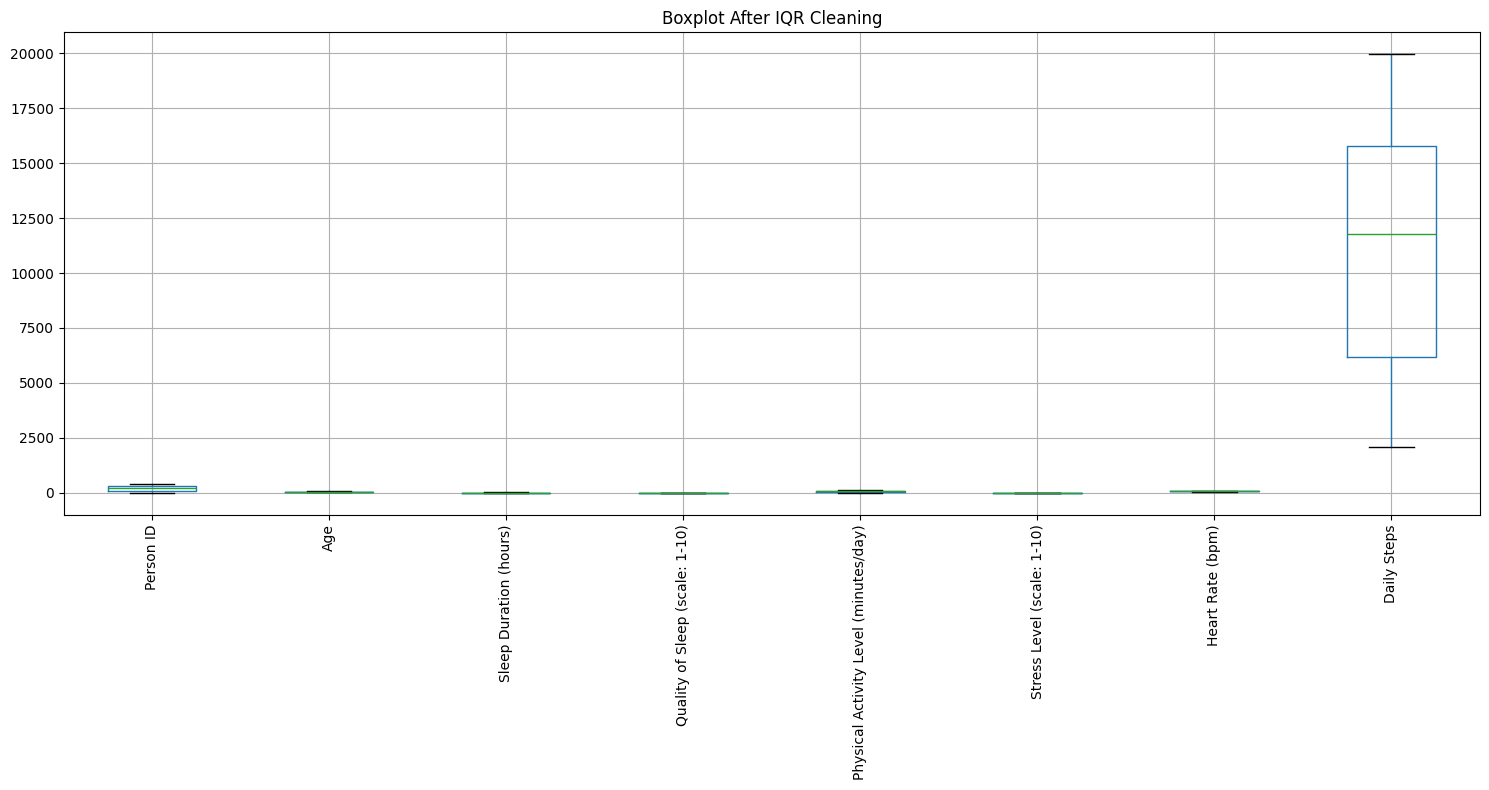

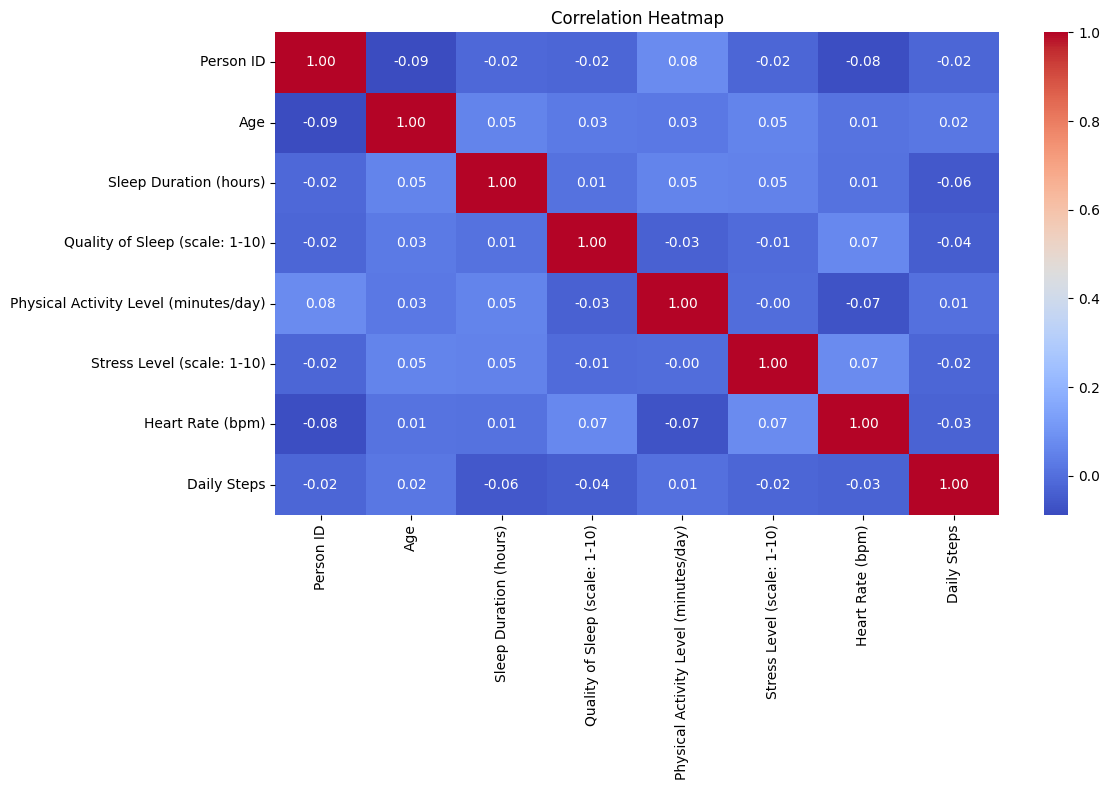


Data Cleaning Completed Successfully


In [ ]:
# Refresh numeric columns after all cleaning
numeric_cols = df.select_dtypes(include='number').columns.tolist()

df.to_csv("cleaned_dataset.csv", index=False)

print("\nCleaned Dataset Saved Successfully")

# Boxplot
if len(numeric_cols) > 0:
    plt.figure(figsize=(15,8))
    df[numeric_cols].boxplot(rot=90)
    plt.title("Boxplot After IQR Cleaning")
    plt.tight_layout()
    plt.show()

# Heatmap
if len(numeric_cols) > 1:
    plt.figure(figsize=(12,8))
    sns.heatmap(
        df[numeric_cols].corr(),
        annot=True,
        cmap="coolwarm",
        fmt=".2f"
    )
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()

print("\nData Cleaning Completed Successfully")

In [ ]:
df = pd.read_csv("/content/cleaned_dataset.csv")

In [ ]:
X = df[['Age', 'Physical Activity Level (minutes/day)', 'Stress Level (scale: 1-10)', 'Heart Rate (bpm)', 'Daily Steps']]
y = df['Sleep Duration (hours)']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: -1.2695324630677383
MSE: 11.202125
